1. Imports y carga de dataset

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Cargar datos
df = pd.read_csv("../data/input/train_olivar.csv")

df.head()

,parcel_id,zona_provincia,tipo_olivar,riego,superficie_ha,variedad,estado_fenologico,tipo_suelo,drenaje,pendiente_%,...,rain_7d_mm,temp_media_7d,humedad_suelo_%,profundidad_suelo_cm,materia_organica_%,rendimiento_esperado_kg_ha,precio_mercado_eur_kg,coste_variable_ha,duracion_encharcamiento_dias,pct_perdida
0,OLV_42_0000,Córdoba,Tradicional,Secano,41.54,Picual,Reposo,Arcilloso,Moderado,1.5,...,186.5,17.4,82.0,64,2.84,5605,0.89,961,2.75,0.0000
1,OLV_42_0001,Jaén,Intensivo,Riego,32.67,Picual,Reposo,Franco,Malo,3.7,...,229.3,13.1,71.0,90,1.08,10571,0.83,1580,4.57,0.0262
2,OLV_42_0002,Jaén,Tradicional,Riego,3.34,Hojiblanca,Engorde,Limoso,Moderado,5.9,...,197.6,13.1,39.1,98,2.94,10030,0.81,1374,1.98,0.0000
3,OLV_42_0003,Sevilla,Intensivo,Riego,6.30,Manzanilla,Floracion,Limoso,Malo,8.5,...,142.5,13.5,67.0,55,1.38,10811,0.81,1790,2.01,0.0000
4,OLV_42_0004,Córdoba,Intensivo,Secano,34.86,Picual,Floracion,Arenoso,Moderado,0.6,...,341.9,15.8,24.0,30,0.98,6738,0.77,1152,1.40,0.0220


2. Crear variable objetivo (impacto)

In [2]:
df["impacto_eur_ha"] = (
    df["rendimiento_esperado_kg_ha"] *
    df["pct_perdida"] *
    df["precio_mercado_eur_kg"]
)

df[["pct_perdida", "impacto_eur_ha"]].describe()

,pct_perdida,impacto_eur_ha
count,3000.000000,3000.000000
mean,0.044381,274.187550
std,0.092241,647.139504
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.039025,211.344624
max,0.550000,8430.109970


3. Vista general del dataset

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcel_id                     3000 non-null   object 
 1   zona_provincia                3000 non-null   object 
 2   tipo_olivar                   3000 non-null   object 
 3   riego                         3000 non-null   object 
 4   superficie_ha                 3000 non-null   float64
 5   variedad                      3000 non-null   object 
 6   estado_fenologico             3000 non-null   object 
 7   tipo_suelo                    3000 non-null   object 
 8   drenaje                       3000 non-null   object 
 9   pendiente_%                   3000 non-null   float64
 10  distancia_rio_m               3000 non-null   float64
 11  altitud_m                     3000 non-null   float64
 12  rain_72h_mm                   2980 non-null   float64
 13  rai

parcel_id                        0
zona_provincia                   0
tipo_olivar                      0
riego                            0
superficie_ha                    0
variedad                         0
estado_fenologico                0
tipo_suelo                       0
drenaje                          0
pendiente_%                      0
distancia_rio_m                  0
altitud_m                        0
rain_72h_mm                     20
rain_7d_mm                       0
temp_media_7d                    0
humedad_suelo_%                  0
profundidad_suelo_cm             0
materia_organica_%               0
rendimiento_esperado_kg_ha       0
precio_mercado_eur_kg            0
coste_variable_ha                0
duracion_encharcamiento_dias     0
pct_perdida                      0
impacto_eur_ha                   0
dtype: int64

4. Distribución del impacto (CRÍTICO)

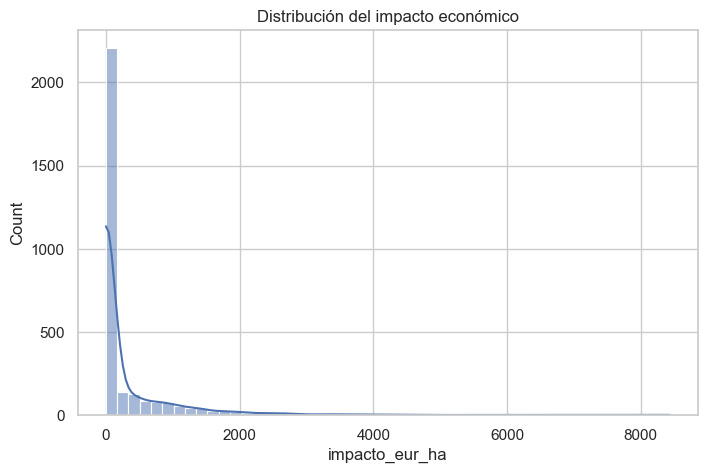

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["impacto_eur_ha"], bins=50, kde=True)
plt.title("Distribución del impacto económico")
plt.show()

Muchísimos valores cercanos a 0
Pocos valores extremadamente altos

Interpretación:
- El riesgo económico es: frecuente pero bajo

el grafico muestra un sesgado bastante alto a la derecha, por tanto se aplicara el logaritmo a la variable: 

In [5]:
df["impacto_log"] = np.log1p(df["impacto_eur_ha"])

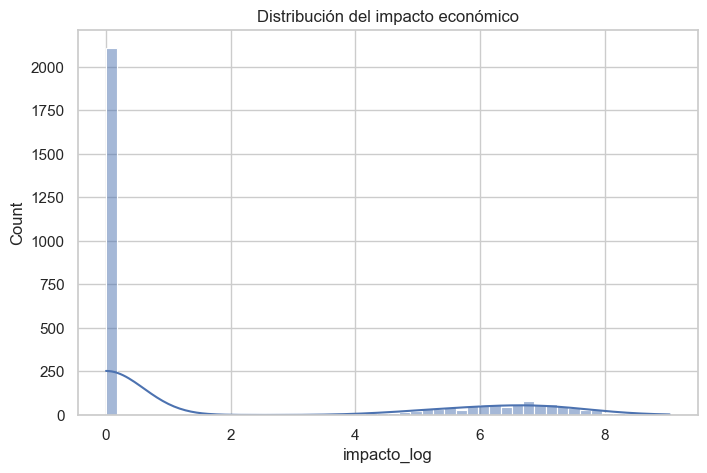

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["impacto_log"], bins=50, kde=True)
plt.title("Distribución del impacto económico")
plt.show()

5. Relación lluvia → impacto

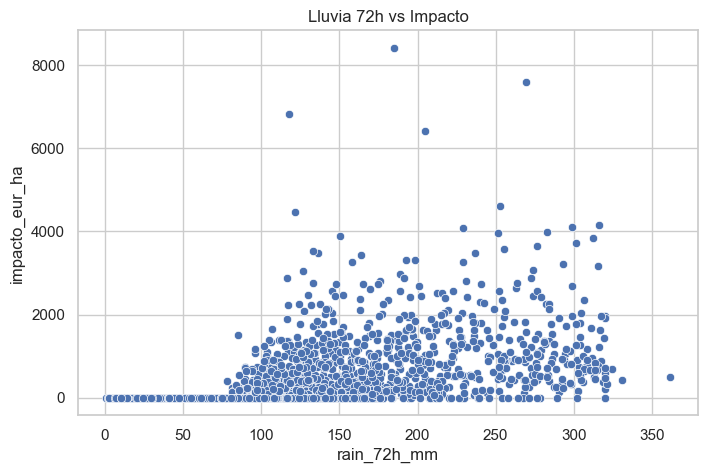

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="rain_72h_mm", y="impacto_eur_ha", data=df)
plt.title("Lluvia 72h vs Impacto")
plt.show()

<Axes: xlabel='rain_7d_mm', ylabel='impacto_eur_ha'>

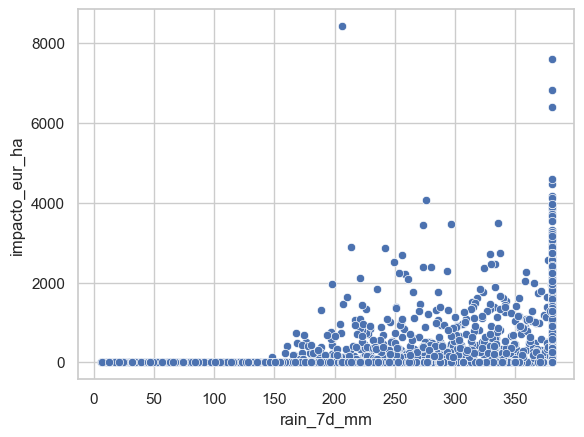

In [8]:
sns.scatterplot(x="rain_7d_mm", y="impacto_eur_ha", data=df)

6. Pendiente → impacto 

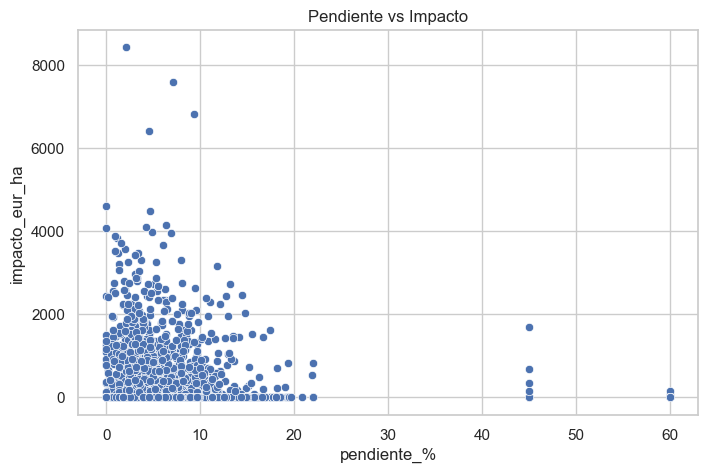

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="pendiente_%", y="impacto_eur_ha", data=df)
plt.title("Pendiente vs Impacto")
plt.show()

7. Encharcamiento → impacto (TOP VARIABLE)

<Axes: xlabel='duracion_encharcamiento_dias', ylabel='impacto_eur_ha'>

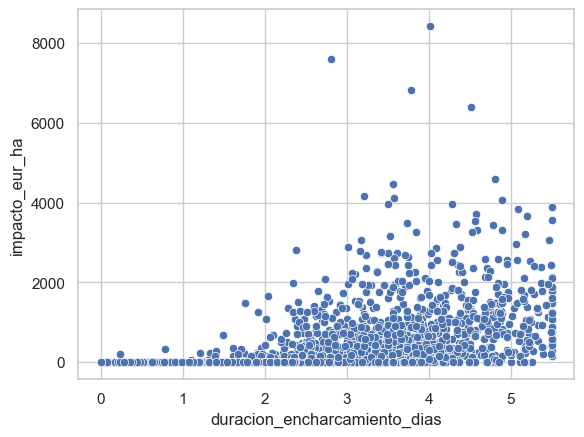

In [10]:
sns.scatterplot(
    x="duracion_encharcamiento_dias",
    y="impacto_eur_ha",
    data=df
)

8. Suelo y drenaje

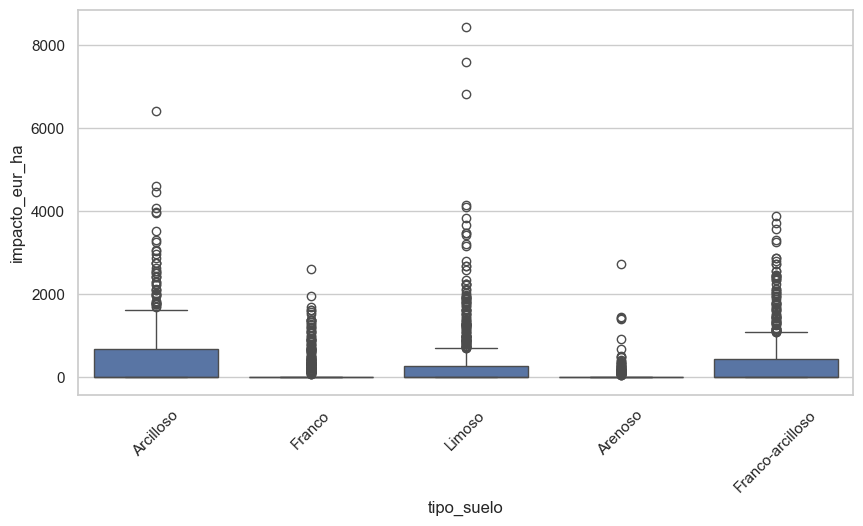

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x="tipo_suelo", y="impacto_eur_ha", data=df)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='drenaje', ylabel='impacto_eur_ha'>

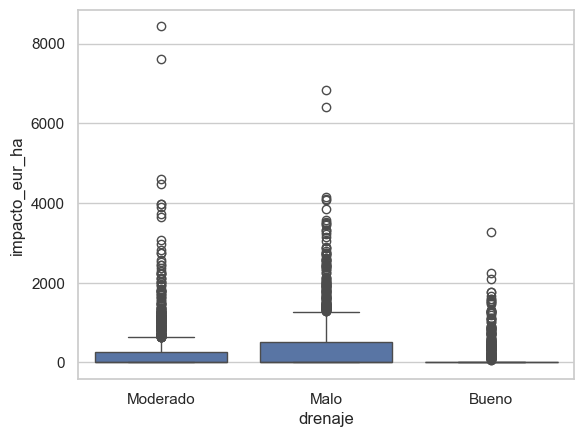

In [12]:
sns.boxplot(x="drenaje", y="impacto_eur_ha", data=df)

9. Estado fenológico

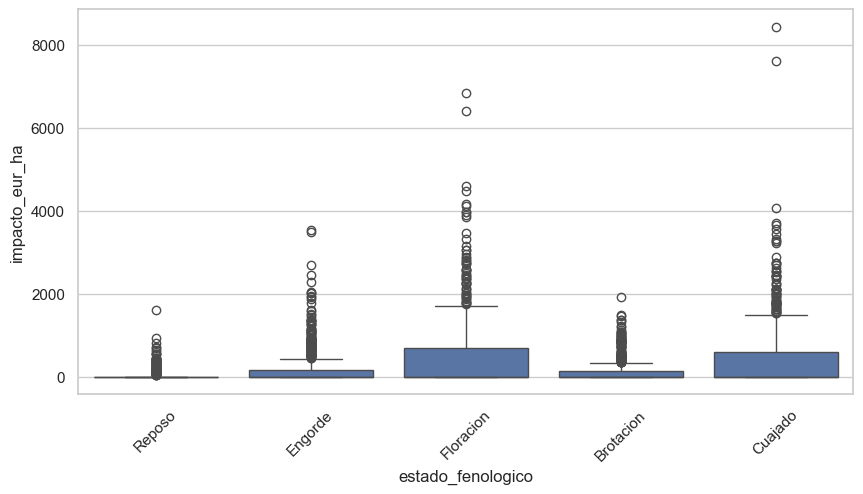

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x="estado_fenologico", y="impacto_eur_ha", data=df)
plt.xticks(rotation=45)
plt.show()

10. Correlación (numéricas)

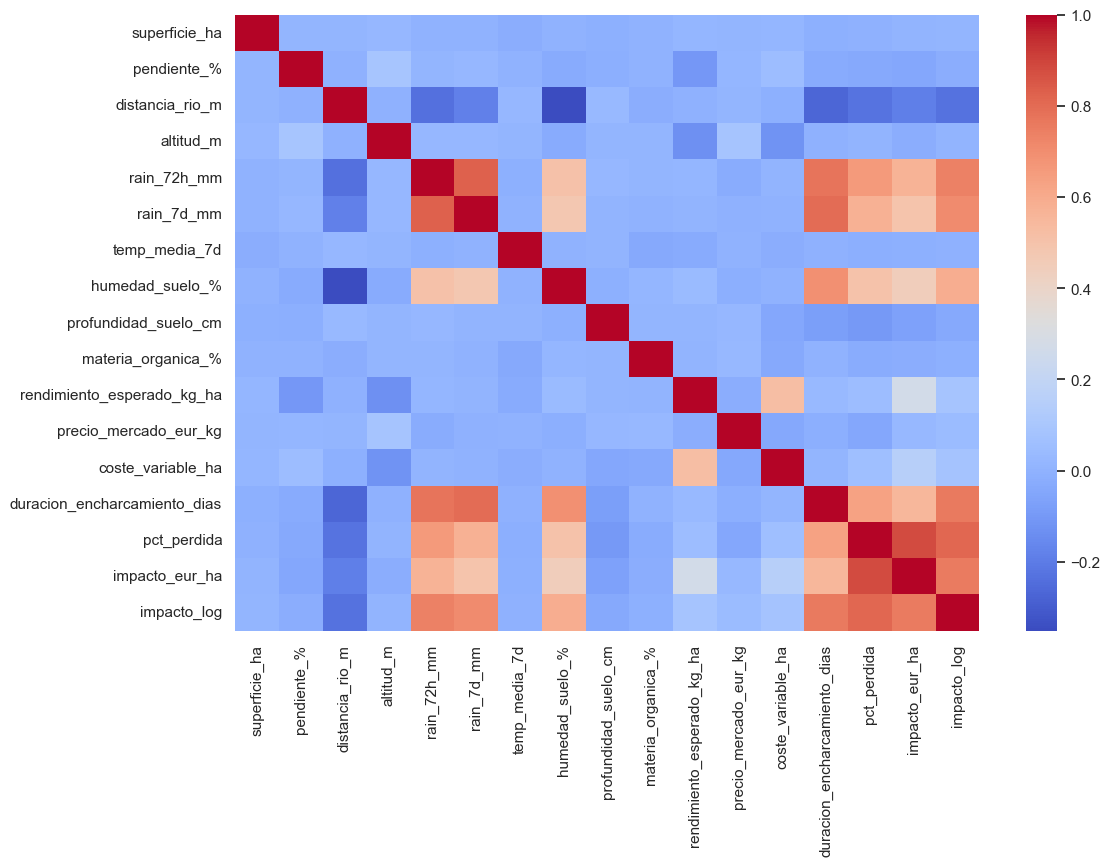

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

# 1. Preparación de datos

Separar variables

In [15]:
import pandas as pd

cols_to_drop = ["pct_perdida", "impacto_eur_ha", "impacto_log", "parcel_id"]

X = df.drop(columns=cols_to_drop)
y = df["pct_perdida"]

Tipos de variables

In [16]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categoricas:", cat_cols)
print("Numericas:", num_cols)

Categoricas: ['zona_provincia', 'tipo_olivar', 'riego', 'variedad', 'estado_fenologico', 'tipo_suelo', 'drenaje']
Numericas: ['superficie_ha', 'pendiente_%', 'distancia_rio_m', 'altitud_m', 'rain_72h_mm', 'rain_7d_mm', 'temp_media_7d', 'humedad_suelo_%', 'profundidad_suelo_cm', 'materia_organica_%', 'rendimiento_esperado_kg_ha', 'precio_mercado_eur_kg', 'coste_variable_ha', 'duracion_encharcamiento_dias']


Train / Test split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

2. Preprocesamiento  
Encoding + escalado

In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

# MODELO 1: (RandomForest)

In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

4. Pipeline completo

In [20]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

5. Entrenamiento

In [21]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


6. Evaluación

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = pipeline.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 0.0131
RMSE: 0.0298
R2: 0.8895


7. Calcular impacto (VALIDACIÓN)

In [23]:
X_val_copy = X_val.copy()

X_val_copy["pct_perdida_pred"] = y_pred

X_val_copy["impacto_pred"] = (
    X_val_copy["rendimiento_esperado_kg_ha"] *
    X_val_copy["pct_perdida_pred"] *
    X_val_copy["precio_mercado_eur_kg"]
)

8. Métrica de negocio

In [24]:
impacto_real = (
    X_val["rendimiento_esperado_kg_ha"] *
    y_val *
    X_val["precio_mercado_eur_kg"]
)

from sklearn.metrics import mean_absolute_error

mae_impacto = mean_absolute_error(impacto_real, X_val_copy["impacto_pred"])

print(f"MAE Impacto (€): {mae_impacto:.2f}")

MAE Impacto (€): 77.26


9. Importancia de variables

In [25]:
import numpy as np

feature_names = (
    num_cols +
    list(pipeline.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .get_feature_names_out(cat_cols))
)

importances = pipeline.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
4,rain_72h_mm,0.284463
13,duracion_encharcamiento_dias,0.248899
7,humedad_suelo_%,0.093881
34,estado_fenologico_Reposo,0.075195
33,estado_fenologico_Floracion,0.049405
8,profundidad_suelo_cm,0.044926
31,estado_fenologico_Cuajado,0.040349
30,estado_fenologico_Brotacion,0.027228
32,estado_fenologico_Engorde,0.025834
5,rain_7d_mm,0.025000


# 2. MODELO 2: Gradient Boosting

Definir modelo

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

Pipeline

In [31]:
gbr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", gbr_model)
])

Entrenar

In [32]:
gbr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 3. Evaluación (comparación modelos)

In [33]:
# RandomForest
y_pred_rf = pipeline.predict(X_val)

# Gradient Boosting
y_pred_gbr = gbr_pipeline.predict(X_val)

Métricas

In [34]:
def evaluar(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n {nombre}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")

evaluar(y_val, y_pred_rf, "RandomForest")
evaluar(y_val, y_pred_gbr, "GradientBoosting")


 RandomForest
MAE: 0.0131
RMSE: 0.0298
R2: 0.8895

 GradientBoosting
MAE: 0.0142
RMSE: 0.0263
R2: 0.9139


4. Comparación de negocio

In [35]:
def impacto_mae(X_val, y_true, y_pred, nombre):
    impacto_real = (
        X_val["rendimiento_esperado_kg_ha"] *
        y_true *
        X_val["precio_mercado_eur_kg"]
    )

    impacto_pred = (
        X_val["rendimiento_esperado_kg_ha"] *
        y_pred *
        X_val["precio_mercado_eur_kg"]
    )

    mae_imp = mean_absolute_error(impacto_real, impacto_pred)

    print(f"{nombre} → MAE Impacto (€): {mae_imp:.2f}")

impacto_mae(X_val, y_val, y_pred_rf, "RandomForest")
impacto_mae(X_val, y_val, y_pred_gbr, "GradientBoosting")

RandomForest → MAE Impacto (€): 77.26
GradientBoosting → MAE Impacto (€): 83.05


# 3. Modelo 3: HistGradientBoosting

In [39]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline

# Modelo
hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Pipeline
hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", hgb_model)
])

# Entrenamiento
hgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_hgb = hgb_pipeline.predict(X_val)

mae_hgb = mean_absolute_error(y_val, y_pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(y_val, y_pred_hgb))
r2_hgb = r2_score(y_val, y_pred_hgb)

print("HistGradientBoosting")
print(f"MAE: {mae_hgb:.4f}")
print(f"RMSE: {rmse_hgb:.4f}")
print(f"R2: {r2_hgb:.4f}")

HistGradientBoosting
MAE: 0.0109
RMSE: 0.0228
R2: 0.9354


In [41]:
# Impacto real
impacto_real = (
    X_val["rendimiento_esperado_kg_ha"] *
    y_val *
    X_val["precio_mercado_eur_kg"]
)

# Impacto predicho
impacto_pred_hgb = (
    X_val["rendimiento_esperado_kg_ha"] *
    y_pred_hgb *
    X_val["precio_mercado_eur_kg"]
)

mae_impacto_hgb = mean_absolute_error(impacto_real, impacto_pred_hgb)

print(f"MAE Impacto (€): {mae_impacto_hgb:.2f}")

MAE Impacto (€): 65.65


In [36]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance(pipeline, num_cols, cat_cols, title="Feature Importance"):
    
    # Obtener nombres de features
    feature_names = (
        num_cols +
        list(pipeline.named_steps["preprocessor"]
             .named_transformers_["cat"]
             .get_feature_names_out(cat_cols))
    )
    
    # Importancias
    importances = pipeline.named_steps["model"].feature_importances_
    
    # DataFrame
    feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)
    
    # Top 15
    feat_imp = feat_imp.head(15)
    
    # Plot
    plt.figure(figsize=(10,6))
    plt.barh(feat_imp["feature"], feat_imp["importance"])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("Importance")
    plt.show()
    
    return feat_imp

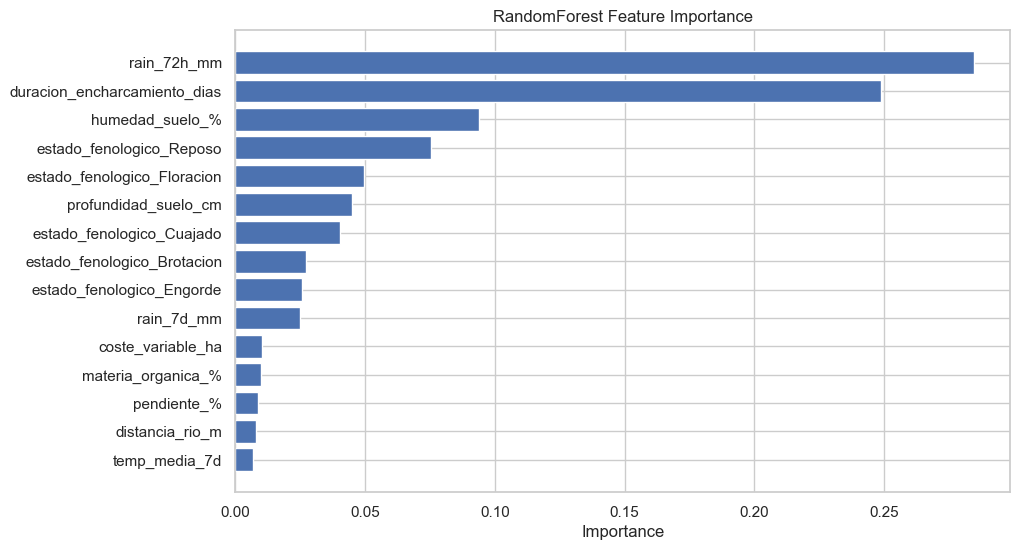

In [37]:
feat_rf = plot_feature_importance(
    pipeline,
    num_cols,
    cat_cols,
    title="RandomForest Feature Importance"
)

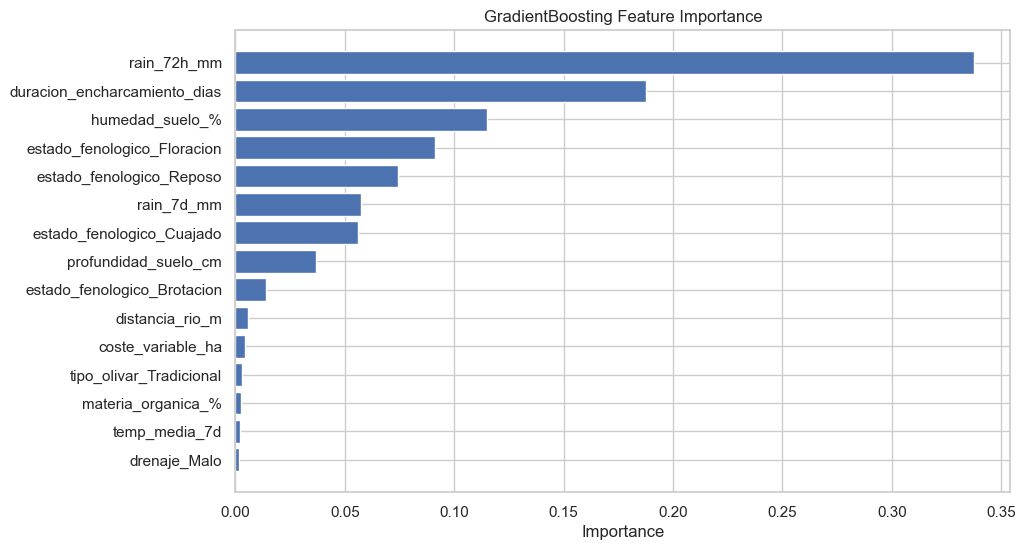

In [38]:
feat_gbr = plot_feature_importance(
    gbr_pipeline,
    num_cols,
    cat_cols,
    title="GradientBoosting Feature Importance"
)

# Comparación completa (3 modelos)

Predicciones

In [43]:
y_pred_rf = pipeline.predict(X_val)
y_pred_gbr = gbr_pipeline.predict(X_val)
y_pred_hgb = hgb_pipeline.predict(X_val)

Métricas 

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluar(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

metrics_rf = evaluar(y_val, y_pred_rf)
metrics_gbr = evaluar(y_val, y_pred_gbr)
metrics_hgb = evaluar(y_val, y_pred_hgb)

Métrica de negocio

In [47]:
def impacto_mae(y_true, y_pred):
    impacto_real = (
        X_val["rendimiento_esperado_kg_ha"] *
        y_true *
        X_val["precio_mercado_eur_kg"]
    )
    
    impacto_pred = (
        X_val["rendimiento_esperado_kg_ha"] *
        y_pred *
        X_val["precio_mercado_eur_kg"]
    )
    
    return mean_absolute_error(impacto_real, impacto_pred)

impact_rf = impacto_mae(y_val, y_pred_rf)
impact_gbr = impacto_mae(y_val, y_pred_gbr)
impact_hgb = impacto_mae(y_val, y_pred_hgb)

Tabla comparativa FINAL

In [48]:
results = {
    "Modelo": ["RandomForest", "GradientBoosting", "HistGradientBoosting"],
    "MAE": [metrics_rf["MAE"], metrics_gbr["MAE"], metrics_hgb["MAE"]],
    "RMSE": [metrics_rf["RMSE"], metrics_gbr["RMSE"], metrics_hgb["RMSE"]],
    "R2": [metrics_rf["R2"], metrics_gbr["R2"], metrics_hgb["R2"]],
    "MAE_Impacto (€)": [impact_rf, impact_gbr, impact_hgb]
}

df_results = pd.DataFrame(results).sort_values("MAE_Impacto (€)")

df_results

,Modelo,MAE,RMSE,R2,MAE_Impacto (€)
2,HistGradientBoosting,0.010933,0.022754,0.935391,65.647564
0,RandomForest,0.013081,0.029753,0.889533,77.255839
1,GradientBoosting,0.014188,0.026263,0.913931,83.053376


# Analisis de resultados 

## 1. Análisis de variables

Los modelos coinciden en:  
Variables clave:  

- rain_72h_mm
- duracion_encharcamiento_dias
- humedad_suelo_%
- estado_fenologico
- profundidad_suelo_cm

## 2. Comparación de modelos

| Modelo                  | MAE    | RMSE   | R²     | MAE Impacto (€) |
| ----------------------- | ------ | ------ | ------ | --------------- |
| 🥇 HistGradientBoosting | 0.0109 | 0.0228 | 0.9354 | **65.65**       |
| 🥈 RandomForest         | 0.0131 | 0.0298 | 0.8895 | 77.26           |
| 🥉 GradientBoosting     | 0.0142 | 0.0263 | 0.9139 | 83.05           |


1. Modelo ganador
HistGradientBoosting es el mejor modelo en TODAS las métricas

✔ Menor MAE  
✔ Menor RMSE  
✔ Mayor R²  
✔ Menor error económico  

2. Impacto en negocio
Comparación clave:

- HGB → 65.65 €
- RF → 77.26 €
- GBR → 83.05 €

Mejora de HistGradientBoosting vs RandomForest: ≈ 11.6 € por parcela

- En 3000 parcelas: ≈ 34,800 € de mejora


Se evaluaron tres modelos de machine learning: RandomForest, GradientBoosting y HistGradientBoosting.

El modelo HistGradientBoosting obtuvo el mejor desempeño en todas las métricas evaluadas, destacando especialmente en la métrica de negocio (MAE del impacto económico), con un error medio de 65.65 € por parcela.

Esto supone una mejora significativa respecto a RandomForest (77.26 €) y GradientBoosting (83.05 €), lo que representa una reducción del error económico de aproximadamente 34,800 € en el conjunto total de parcelas.

Por tanto, se selecciona HistGradientBoosting como modelo final, al ser el que mejor minimiza el error en términos económicos, que es el objetivo principal del problema.

# Generar predicciones en data test con modelo HistGradientBoosting
1. Cargar dataset de TEST

In [52]:
df_test  = pd.read_csv("../data/input/test_olivar.csv", sep=";")

df_test

,parcel_id,zona_provincia,tipo_olivar,riego,superficie_ha,variedad,estado_fenologico,tipo_suelo,drenaje,pendiente_%,...,rain_72h_mm,rain_7d_mm,temp_media_7d,humedad_suelo_%,profundidad_suelo_cm,materia_organica_%,rendimiento_esperado_kg_ha,precio_mercado_eur_kg,coste_variable_ha,duracion_encharcamiento_dias
0,TEST_01,Jaén,Tradicional,Secano,12.5,Picual,Brotacion,Franco,Bueno,9.0,...,10.0,22.0,16.5,28.1,98,1.6,5000,0.82,1150,0.00
1,TEST_02,Cadiz,Intensivo,Secano,17.8,Manzanilla,Engorde,Arenoso,Bueno,18.0,...,85.0,140.0,18.0,27.1,108,1.0,6100,0.77,1380,0.13
2,TEST_03,Granada,Tradicional,Secano,9.6,Picual,Floracion,Franco,Bueno,11.0,...,105.0,175.0,15.2,28.2,92,1.7,5050,0.83,1240,1.00
3,TEST_04,Córdoba,Intensivo,Riego,20.5,Hojiblanca,Cuajado,Franco-arcilloso,Malo,3.0,...,118.0,210.0,17.3,74.1,80,1.8,9600,0.80,1580,3.70
4,TEST_05,Sevilla,Intensivo,Riego,24.2,Manzanilla,Floracion,Limoso,Moderado,3.2,...,128.0,235.0,18.2,68.7,72,1.9,9950,0.77,1690,3.65
5,TEST_06,Córdoba,Tradicional,Secano,13.8,Picual,Cuajado,Franco-arcilloso,Moderado,2.8,...,145.0,265.0,17.0,68.5,70,1.5,5400,0.82,1270,3.97
6,TEST_07,Málaga,Superintensivo,Riego,29.0,Arbequina,Floracion,Franco,Moderado,1.5,...,155.0,270.0,18.6,66.9,86,1.5,10800,0.88,1830,3.64
7,TEST_08,Córdoba,Tradicional,Secano,14.2,Picual,Cuajado,Arcilloso,Malo,1.8,...,210.0,330.0,17.1,76.7,58,1.5,5250,0.82,1290,5.03
8,TEST_09,Sevilla,Tradicional,Secano,11.5,Manzanilla,Cuajado,Limoso,Malo,1.3,...,165.0,340.0,18.8,75.0,63,1.7,4850,0.78,1210,4.65
9,TEST_10,Granada,Intensivo,Riego,22.8,Picual,Cuajado,Arcilloso,Malo,1.0,...,260.0,380.0,16.8,76.9,54,1.4,9300,0.83,1710,5.17


In [60]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcel_id                     10 non-null     object 
 1   zona_provincia                10 non-null     object 
 2   tipo_olivar                   10 non-null     object 
 3   riego                         10 non-null     object 
 4   superficie_ha                 10 non-null     float64
 5   variedad                      10 non-null     object 
 6   estado_fenologico             10 non-null     object 
 7   tipo_suelo                    10 non-null     object 
 8   drenaje                       10 non-null     object 
 9   pendiente_%                   10 non-null     float64
 10  distancia_rio_m               10 non-null     float64
 11  altitud_m                     10 non-null     float64
 12  rain_72h_mm                   10 non-null     float64
 13  rain_7d_

2. Preparar features

In [53]:
cols_to_drop = ["parcel_id"]  

X_test = df_test.drop(columns=cols_to_drop)

3. Predicción con el modelo ganador

In [61]:
final_model = hgb_pipeline


y_test_pred = final_model.predict(X_test)

df_test["pct_perdida_pred"] = y_test_pred

df_test["pct_perdida_pred"] = df_test["pct_perdida_pred"].clip(0, 1)

4. Calcular impacto económico

In [62]:
df_test["impacto_eur_ha_pred"] = (
    df_test["rendimiento_esperado_kg_ha"] *
    df_test["pct_perdida_pred"] *
    df_test["precio_mercado_eur_kg"]
)

In [63]:
df_test

,parcel_id,zona_provincia,tipo_olivar,riego,superficie_ha,variedad,estado_fenologico,tipo_suelo,drenaje,pendiente_%,...,temp_media_7d,humedad_suelo_%,profundidad_suelo_cm,materia_organica_%,rendimiento_esperado_kg_ha,precio_mercado_eur_kg,coste_variable_ha,duracion_encharcamiento_dias,pct_perdida_pred,impacto_eur_ha_pred
0,TEST_01,Jaén,Tradicional,Secano,12.5,Picual,Brotacion,Franco,Bueno,9.0,...,16.5,28.1,98,1.6,5000,0.82,1150,0.00,0.000000,0.000000
1,TEST_02,Cadiz,Intensivo,Secano,17.8,Manzanilla,Engorde,Arenoso,Bueno,18.0,...,18.0,27.1,108,1.0,6100,0.77,1380,0.13,0.000000,0.000000
2,TEST_03,Granada,Tradicional,Secano,9.6,Picual,Floracion,Franco,Bueno,11.0,...,15.2,28.2,92,1.7,5050,0.83,1240,1.00,0.009223,38.656274
3,TEST_04,Córdoba,Intensivo,Riego,20.5,Hojiblanca,Cuajado,Franco-arcilloso,Malo,3.0,...,17.3,74.1,80,1.8,9600,0.80,1580,3.70,0.112835,866.569138
4,TEST_05,Sevilla,Intensivo,Riego,24.2,Manzanilla,Floracion,Limoso,Moderado,3.2,...,18.2,68.7,72,1.9,9950,0.77,1690,3.65,0.176220,1350.108293
5,TEST_06,Córdoba,Tradicional,Secano,13.8,Picual,Cuajado,Franco-arcilloso,Moderado,2.8,...,17.0,68.5,70,1.5,5400,0.82,1270,3.97,0.234869,1039.997890
6,TEST_07,Málaga,Superintensivo,Riego,29.0,Arbequina,Floracion,Franco,Moderado,1.5,...,18.6,66.9,86,1.5,10800,0.88,1830,3.64,0.263019,2499.735427
7,TEST_08,Córdoba,Tradicional,Secano,14.2,Picual,Cuajado,Arcilloso,Malo,1.8,...,17.1,76.7,58,1.5,5250,0.82,1290,5.03,0.350438,1508.635754
8,TEST_09,Sevilla,Tradicional,Secano,11.5,Manzanilla,Cuajado,Limoso,Malo,1.3,...,18.8,75.0,63,1.7,4850,0.78,1210,4.65,0.300787,1137.876211
9,TEST_10,Granada,Intensivo,Riego,22.8,Picual,Cuajado,Arcilloso,Malo,1.0,...,16.8,76.9,54,1.4,9300,0.83,1710,5.17,0.486494,3755.250875


5. Métricas agregadas

In [64]:
impacto_total = df_test["impacto_eur_ha_pred"].sum()
impacto_promedio = df_test["impacto_eur_ha_pred"].mean()
impacto_max = df_test["impacto_eur_ha_pred"].max()

print(f"💰 Impacto total (€): {impacto_total:,.2f}")
print(f"📊 Impacto promedio (€ / ha): {impacto_promedio:.2f}")
print(f"⚠️ Impacto máximo (€): {impacto_max:.2f}")

💰 Impacto total (€): 12,196.83
📊 Impacto promedio (€ / ha): 1219.68
⚠️ Impacto máximo (€): 3755.25


6. Top parcelas más afectadas

In [71]:
top_parcelas = df_test.sort_values("impacto_eur_ha_pred", ascending=False).head(10)

top_parcelas[[
    "parcel_id",
    "pct_perdida_pred",
    "impacto_eur_ha_pred",
    "rain_72h_mm",
    "duracion_encharcamiento_dias"
]]

top_parcelas

,parcel_id,zona_provincia,tipo_olivar,riego,superficie_ha,variedad,estado_fenologico,tipo_suelo,drenaje,pendiente_%,...,temp_media_7d,humedad_suelo_%,profundidad_suelo_cm,materia_organica_%,rendimiento_esperado_kg_ha,precio_mercado_eur_kg,coste_variable_ha,duracion_encharcamiento_dias,pct_perdida_pred,impacto_eur_ha_pred
9,TEST_10,Granada,Intensivo,Riego,22.8,Picual,Cuajado,Arcilloso,Malo,1.0,...,16.8,76.9,54,1.4,9300,0.83,1710,5.17,0.486494,3755.250875
6,TEST_07,Málaga,Superintensivo,Riego,29.0,Arbequina,Floracion,Franco,Moderado,1.5,...,18.6,66.9,86,1.5,10800,0.88,1830,3.64,0.263019,2499.735427
7,TEST_08,Córdoba,Tradicional,Secano,14.2,Picual,Cuajado,Arcilloso,Malo,1.8,...,17.1,76.7,58,1.5,5250,0.82,1290,5.03,0.350438,1508.635754
4,TEST_05,Sevilla,Intensivo,Riego,24.2,Manzanilla,Floracion,Limoso,Moderado,3.2,...,18.2,68.7,72,1.9,9950,0.77,1690,3.65,0.176220,1350.108293
8,TEST_09,Sevilla,Tradicional,Secano,11.5,Manzanilla,Cuajado,Limoso,Malo,1.3,...,18.8,75.0,63,1.7,4850,0.78,1210,4.65,0.300787,1137.876211
5,TEST_06,Córdoba,Tradicional,Secano,13.8,Picual,Cuajado,Franco-arcilloso,Moderado,2.8,...,17.0,68.5,70,1.5,5400,0.82,1270,3.97,0.234869,1039.997890
3,TEST_04,Córdoba,Intensivo,Riego,20.5,Hojiblanca,Cuajado,Franco-arcilloso,Malo,3.0,...,17.3,74.1,80,1.8,9600,0.80,1580,3.70,0.112835,866.569138
2,TEST_03,Granada,Tradicional,Secano,9.6,Picual,Floracion,Franco,Bueno,11.0,...,15.2,28.2,92,1.7,5050,0.83,1240,1.00,0.009223,38.656274
1,TEST_02,Cadiz,Intensivo,Secano,17.8,Manzanilla,Engorde,Arenoso,Bueno,18.0,...,18.0,27.1,108,1.0,6100,0.77,1380,0.13,0.000000,0.000000
0,TEST_01,Jaén,Tradicional,Secano,12.5,Picual,Brotacion,Franco,Bueno,9.0,...,16.5,28.1,98,1.6,5000,0.82,1150,0.00,0.000000,0.000000


In [74]:
submission = df_test[[
    "parcel_id",
    "pct_perdida_pred",
    "impacto_eur_ha_pred"
]]

submission["pct_perdida_pred"] = submission["pct_perdida_pred"].round(4)
submission["impacto_eur_ha_pred"] = submission["impacto_eur_ha_pred"].round(2)

submission = submission.sort_values("impacto_eur_ha_pred", ascending=False)

submission.to_csv("../data/output/submission_olivar.csv", index=False)

C:\Users\Santiago\AppData\Local\Temp\ipykernel_20544\147757517.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission["pct_perdida_pred"] = submission["pct_perdida_pred"].round(4)
C:\Users\Santiago\AppData\Local\Temp\ipykernel_20544\147757517.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission["impacto_eur_ha_pred"] = submission["impacto_eur_ha_pred"].round(2)


In [75]:
submission

,parcel_id,pct_perdida_pred,impacto_eur_ha_pred
9,TEST_10,0.4865,3755.25
6,TEST_07,0.2630,2499.74
7,TEST_08,0.3504,1508.64
4,TEST_05,0.1762,1350.11
8,TEST_09,0.3008,1137.88
5,TEST_06,0.2349,1040.00
3,TEST_04,0.1128,866.57
2,TEST_03,0.0092,38.66
1,TEST_02,0.0000,0.00
0,TEST_01,0.0000,0.00
